# Análisis exploratorio: Online Retail II

Exploración del dataset de ventas retail online (transacciones, productos, clientes y países).

**Contenido:**
- Carga y primera inspección
- Calidad de datos (nulos, duplicados, tipos)
- Estadísticas descriptivas
- Visualizaciones (distribuciones, series temporales, categorías)
- Conclusiones del EDA

**Dudas**  
¿cómo calcula los revenues?
tendría sentido quitar cuando tenemos identificada una compra?
varios modelos segun comportamiento del cliente?
entender bien como hace la construccion del data set agregado
 


In [236]:
# pip install openpyxl

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 20)
plt.style.use('ggplot')
sns.set_palette('husl')

## 1. Carga de datos

In [238]:
# Ruta al dataset (ajusta si es necesario)
# DATA_PATH = r'online_retail_II.xlsx'

# # Si el Excel tiene varias hojas, podemos cargar la primera o especificar por nombre
# #df = pd.read_excel(DATA_PATH, sheet_name=1)
# xl = pd.ExcelFile(DATA_PATH)
# df = pd.concat([pd.read_excel(DATA_PATH, sheet_name=s) for s in xl.sheet_names], ignore_index=True)
# print(f'Filas: {len(df):,} | Columnas: {len(df.columns)}')

In [2]:
# df.to_pickle('online_retail.pkl')
df = pd.read_pickle('online_retail.pkl')

## 2. Primera inspección

In [3]:
df.sample(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
543926,537823,84536B,FAIRY CAKES NOTEBOOK A7 SIZE,3,2010-12-08 14:25:00,0.85,NaN,United Kingdom
721081,553730,21621,VINTAGE UNION JACK BUNTING,4,2011-05-19 07:49:00,8.50,16525.0,United Kingdom
273431,515939,22630,DOLLY GIRL LUNCH BOX,1,2010-07-15 15:02:00,4.21,NaN,United Kingdom
1036791,579491,22498,WOODEN REGATTA BUNTING,1,2011-11-29 15:23:00,5.95,14723.0,United Kingdom
299082,518511,20767,BLUE PAISLEY JOURNAL,11,2010-08-09 14:53:00,2.55,NaN,United Kingdom
564259,539595,21189,WHITE HONEYCOMB PAPER GARLAND,8,2010-12-20 13:43:00,3.36,NaN,United Kingdom
350631,523510,22731,3D CHRISTMAS STAMPS STICKERS,6,2010-09-22 12:24:00,1.25,17840.0,United Kingdom
83756,497202,21770,OPEN CLOSED METAL SIGN,1,2010-02-07 11:38:00,4.95,15059.0,United Kingdom
792419,560278,35954,SMALL FOLKART STAR CHRISTMAS DEC,6,2011-07-17 15:45:00,0.42,13610.0,United Kingdom
978215,575384,23355,HOT WATER BOTTLE KEEP CALM,8,2011-11-09 15:17:00,4.95,17690.0,United Kingdom


In [241]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [242]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

## 3. Calidad de datos

In [4]:
# Nulos por columna
print("=== NULOS ===")
print(df.isna().sum())

# Duplicados
print("\n=== DUPLICADOS ===")
print(f"Filas duplicadas: {df.duplicated().sum()}")

# Eliminación de filas duplicadas
print("Tamaño del dataset antes de eliminar duplicados:", df.shape)
df = df.drop_duplicates()
print("Tamaño del dataset después de eliminar duplicados:", df.shape)


=== NULOS ===
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

=== DUPLICADOS ===
Filas duplicadas: 34335
Tamaño del dataset antes de eliminar duplicados: (1067371, 8)
Tamaño del dataset después de eliminar duplicados: (1033036, 8)


In [5]:
# visualizamos los registros con descripción nula
print(df[df['Description'].isna()])

df[df['Description'].isna()].describe()

        Invoice StockCode Description  Quantity         InvoiceDate  Price  \
470      489521     21646         NaN       -50 2009-12-01 11:44:00    0.0   
3114     489655     20683         NaN       -44 2009-12-01 17:26:00    0.0   
3161     489659     21350         NaN       230 2009-12-01 17:39:00    0.0   
3731     489781     84292         NaN        17 2009-12-02 11:45:00    0.0   
4296     489806     18010         NaN      -770 2009-12-02 12:42:00    0.0   
...         ...       ...         ...       ...                 ...    ...   
1060783  581199     84581         NaN        -2 2011-12-07 18:26:00    0.0   
1060787  581203     23406         NaN        15 2011-12-07 18:31:00    0.0   
1060793  581209     21620         NaN         6 2011-12-07 18:35:00    0.0   
1062442  581234     72817         NaN        27 2011-12-08 10:33:00    0.0   
1064015  581408     85175         NaN        20 2011-12-08 14:06:00    0.0   

         Customer ID         Country  
470              NaN  Un

,Quantity,InvoiceDate,Price,Customer ID
count,4275.000000,4275,4275.0,0.0
mean,-17.366784,2010-09-17 17:48:07.480701952,0.0,NaN
min,-9600.000000,2009-12-01 11:44:00,0.0,NaN
25%,-28.000000,2010-03-08 15:32:00,0.0,NaN
50%,-4.000000,2010-08-13 11:46:00,0.0,NaN
75%,3.000000,2011-03-24 10:48:00,0.0,NaN
max,9600.000000,2011-12-08 14:06:00,0.0,NaN
std,515.938734,NaN,0.0,NaN


In [6]:
# Gestión de nulos
# Eliminamos las filas donde 'Customer ID' y Description es nulo.
df = df.dropna(subset=['Customer ID', 'Description'])
# Extaemos las cancelaciones del dataset
cancellations = df[df['Invoice'].astype(str).str.startswith('C')]
# Eliminamos las cancelaciones del dataset
df = df[~df['Invoice'].astype(str).str.startswith('C')]

In [7]:
# Comprobaciones finales

# Clientes y tickets únicos
print("Número de tickets únicos: ", df['Invoice'].nunique())
print("Número de clientes únicos: ", df['Customer ID'].nunique())

# Nulos por columna
print("\n=== NULOS ===")
print(df.isna().sum())

Número de tickets únicos:  36975
Número de clientes únicos:  5881

=== NULOS ===
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


## 4. Estadísticas descriptivas
df.describe()

In [247]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,779495.000000,779495,779495.000000,779495.000000
mean,13.507085,2011-01-03 01:46:36.061116416,3.218199,15320.262918
min,1.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.000000,2010-07-02 14:39:00,1.250000,13971.000000
50%,6.000000,2010-12-02 14:09:00,1.950000,15246.000000
75%,12.000000,2011-08-01 13:48:00,3.750000,16794.000000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000
std,146.540284,NaN,29.674823,1695.722988


In [8]:
# Eliminación de outliers con IQR
def remove_outliers_iqr(df, column, multiplier=1.5):
    """Elimina outliers usando IQR"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    
    outliers_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    
    print(f"\n{column}:")
    print(f"  Rango válido: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers detectados: {outliers_count}")
    
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

print("\n=== ELIMINACIÓN DE OUTLIERS ===")
print("ANTES:", df.shape)
df = remove_outliers_iqr(df, 'Quantity')
df = remove_outliers_iqr(df, 'Price')
cancellations = remove_outliers_iqr(cancellations, 'Quantity')
print("DESPUÉS:", df.shape)

print(df.describe())


=== ELIMINACIÓN DE OUTLIERS ===
ANTES: (779495, 8)

Quantity:
  Rango válido: [-13.00, 27.00]
  Outliers detectados: 51130

Price:
  Rango válido: [-2.50, 7.50]
  Outliers detectados: 64933

Quantity:
  Rango válido: [-13.50, 6.50]
  Outliers detectados: 2037
DESPUÉS: (663432, 8)
            Quantity                    InvoiceDate          Price  \
count  663432.000000                         663432  663432.000000   
mean        7.395433  2011-01-03 07:10:40.623394304       2.275878   
min         1.000000            2009-12-01 07:45:00       0.000000   
25%         2.000000            2010-07-02 12:41:00       1.250000   
50%         6.000000            2010-12-01 17:24:00       1.690000   
75%        12.000000            2011-08-04 10:23:00       2.950000   
max        27.000000            2011-12-09 12:50:00       7.500000   
std         6.709499                            NaN       1.610599   

         Customer ID  
count  663432.000000  
mean    15349.880699  
min     12346.0000

In [9]:
# Filtro para precios
df = df[df['Price'] > 0]

# Comprobación final
print('=== Estadisticas descriptivas ===')
print(df.describe())
print('=== Tipos de datos ===')
print(df.dtypes)
print('=== Formato del DataFrame ===')
print(df.shape)
print('=== Nulos ===')
print(df.isnull().sum())

=== Estadisticas descriptivas ===
            Quantity                    InvoiceDate          Price  \
count  663373.000000                         663373  663373.000000   
mean        7.395559  2011-01-03 07:12:27.716715264       2.276081   
min         1.000000            2009-12-01 07:45:00       0.001000   
25%         2.000000            2010-07-02 12:41:00       1.250000   
50%         6.000000            2010-12-01 17:24:00       1.690000   
75%        12.000000            2011-08-04 10:04:00       2.950000   
max        27.000000            2011-12-09 12:50:00       7.500000   
std         6.709494                            NaN       1.610528   

         Customer ID  
count  663373.000000  
mean    15349.980444  
min     12346.000000  
25%     13999.000000  
50%     15311.000000  
75%     16814.000000  
max     18287.000000  
std      1693.328870  
=== Tipos de datos ===
Invoice                object
StockCode              object
Description            object
Quantity       

In [10]:
# Agrupación y categorización de la columna 'Country'
print('=== Países distintos antes de agrupar ===')
print(df['Country'].value_counts())

# Categoría Others para países con pocas ventas (umbral: menos del 0.5% de las ventas)
country_counts = df['Country'].value_counts()
threshold = 0.005 * country_counts.sum()
df['Country'] = df['Country'].apply(lambda x: 'Others' if country_counts[x] < threshold else x)

print('=== Países distintos después de agrupar ===')
print(df['Country'].value_counts())

=== Países distintos antes de agrupar ===
Country
United Kingdom          603057
Germany                  13570
EIRE                     11785
France                   11126
Spain                     3009
Belgium                   2504
Switzerland               2308
Portugal                  1978
Netherlands               1905
Italy                     1165
Channel Islands           1140
Australia                  946
Norway                     934
Cyprus                     913
Finland                    818
Austria                    783
Sweden                     767
Greece                     541
Denmark                    538
Unspecified                446
Poland                     408
USA                        359
United Arab Emirates       333
Singapore                  250
Israel                     249
Malta                      241
Japan                      215
Iceland                    205
Canada                     203
Lithuania                  141
RSA                 

In [11]:
# Añadimos columna de importe total
df['Revenue'] = df['Quantity'] * df['Price']

## 5. Visualizaciones

Text(0.5, 1.0, 'Raincloud Plot - Quantity')

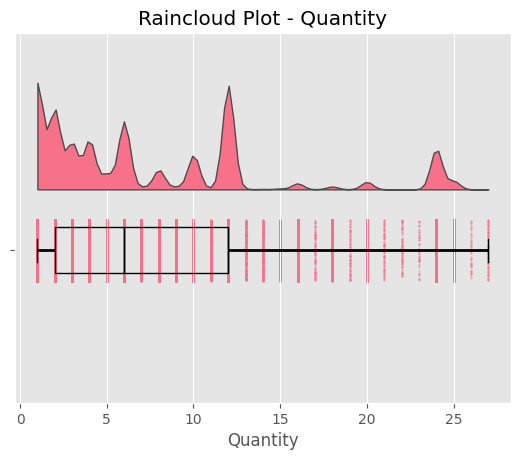

In [12]:
import ptitprince as pt
### importante gestionarla visualizacion cuando hay outliers 
pt.RainCloud(data=df['Quantity'], bw=0.05, cut=0, orient='h', rain_alpha=0.4, point_size=1.5,)
plt.title("Raincloud Plot - Quantity")


La mayoría de valores está entre 0 y 5 pero se observan picos relevantes en 6, 12 y 24. Interesante desde el punto de vista de negocio. Packs, ofertas...

Text(0.5, 1.0, 'Raincloud Plot - Price')

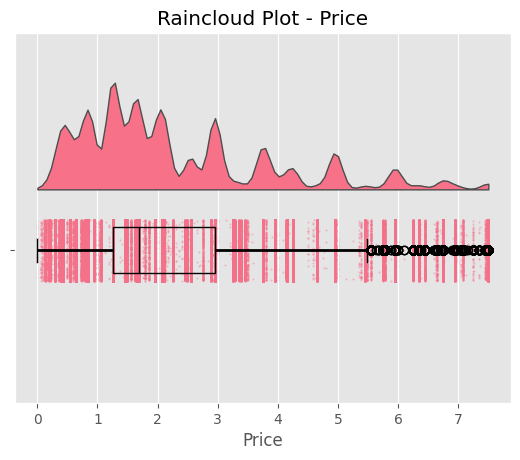

In [13]:
pt.RainCloud(data=df['Price'], bw=0.07, cut=0, orient='h', rain_alpha=0.4, point_size=1.5)
plt.title("Raincloud Plot - Price")

Text(0.5, 1.0, 'Raincloud Plot - Cancellations')

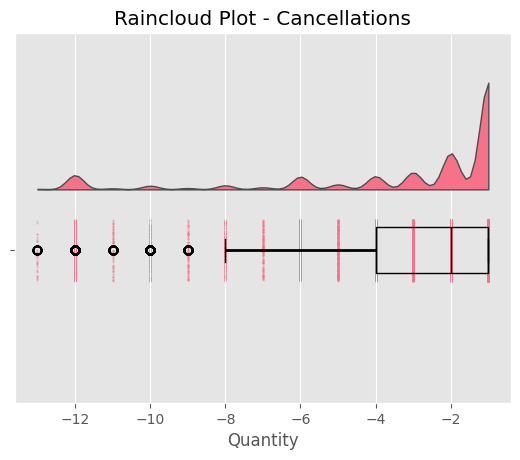

In [14]:
pt.RainCloud(data=cancellations['Quantity'], bw=0.07, cut=0, orient='h', rain_alpha=0.4, point_size=1.5)
plt.title("Raincloud Plot - Cancellations")

Text(0.5, 1.0, 'Ingresos Mensuales')

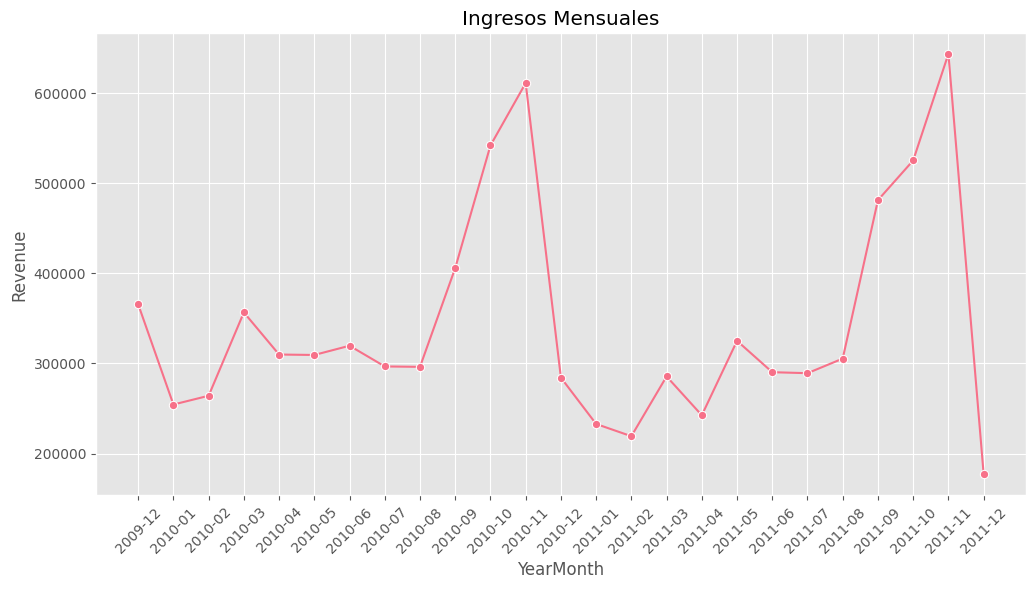

In [15]:
# Ingresos mensuales
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].astype(str)
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_revenue, x='YearMonth', y='Revenue', marker='o')
plt.xticks(rotation=45)
plt.title("Ingresos Mensuales")

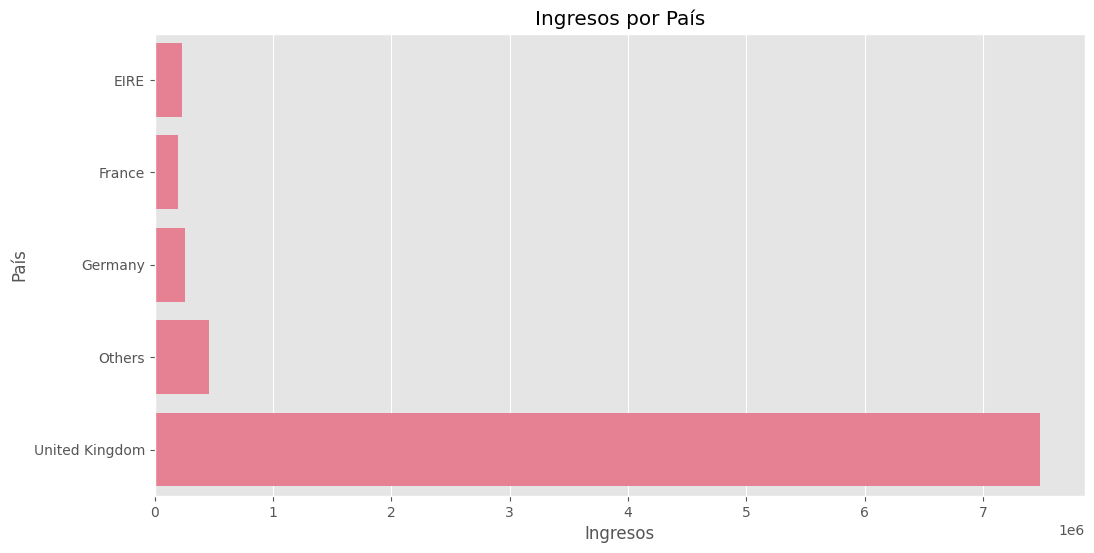

In [16]:
# Gráfico de barras horizontales de ingresos por país
country_revenue = df.groupby('Country')['Revenue'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=country_revenue, x='Revenue', y='Country')
plt.title("Ingresos por País")
plt.xlabel("Ingresos")
plt.ylabel("País")
plt.show()

Mayor volúmen de ingresos entre los meses de septiembre y noviembre. Importante desde el punto de vista de negocio. 
De cara al modelo haremos el corte de datos para predecir la probabilidad de recompra en estos meses. 

## 6. Agrupación por cliente (Customer ID)

Por cada cliente: **suma de tickets en el año** (facturación total), **número de compras** (facturas distintas) y **ticket medio** por compra.

In [17]:
# Segmentacion mayoristas

# añadimos columna año
df['Year'] = df['InvoiceDate'].dt.year

customer_stats_year = df[df['Year'] != 2009].groupby(['Customer ID', 'Year']).agg(
    Total_tickets=('Invoice','nunique'),
    Total_Revenue=('Revenue', 'sum'),
    Avg_Ticket_Revenue=('Revenue', lambda x: round(x.sum() / df.loc[x.index, 'Invoice'].nunique(),2)),
    Avg_Ticket_Quantity=('Quantity', lambda x: round(x.sum() / df.loc[x.index, 'Quantity'].nunique(),))
).reset_index()

customer_stats = customer_stats_year.groupby('Customer ID').agg({
        'Total_tickets': 'mean',
        'Total_Revenue': 'mean',
        'Avg_Ticket_Revenue': 'mean',
        'Avg_Ticket_Quantity': 'mean'
})

# Mayoristas si están en el top 25% de gasto medio y cantidad media de artículos
customer_stats['Is_Wholesale'] = (
        (customer_stats['Total_Revenue'] > customer_stats['Total_Revenue'].quantile(0.75)) & 
        (customer_stats['Avg_Ticket_Quantity'] > customer_stats['Avg_Ticket_Quantity'].quantile(0.75))
        ).astype(int)


In [18]:
# vemos resultados para comprobar si la segmentación tiene sentido
display(customer_stats.sample(10))

,Total_tickets,Total_Revenue,Avg_Ticket_Revenue,Avg_Ticket_Quantity,Is_Wholesale
Customer ID,,,,,
14023.0,2.0,540.770,270.380,38.0,0
15624.0,4.0,511.500,127.880,40.0,0
13515.0,3.0,555.510,173.530,56.5,0
15598.0,1.0,260.535,260.535,36.0,0
17302.0,5.0,1044.480,208.900,47.0,0
16813.0,10.0,1385.570,138.560,93.0,1
12481.0,7.0,3331.035,489.715,198.5,1
15108.0,3.0,983.550,327.850,68.0,0
13868.0,1.0,428.370,428.370,68.0,0


In [19]:
# Agrupamos las cancelaciones por cliente y año
cancellations['Year'] = cancellations['InvoiceDate'].dt.year

cancellations_stats_year = cancellations[cancellations['Year'] != 2009].groupby(['Customer ID', 'Year']).agg(
    Total_Cancellations=('Invoice', 'count')
).reset_index()

cancellations_stats = cancellations_stats_year.groupby('Customer ID').agg(
    total_cancellations=('Total_Cancellations', 'sum')).reset_index()

print(display(cancellations_stats.sample(10)))

,Customer ID,total_cancellations
1598,16158.0,1
1974,17158.0,2
883,14333.0,4
156,12672.0,3
623,13756.0,1
1692,16406.0,2
1261,15290.0,7
919,14430.0,5
1696,16424.0,1
210,12791.0,2


None


## 7. Modelo: probabilidad de recompra

Modelo supervisado para estimar la probabilidad de que un cliente **vuelva a comprar** después de una fecha de corte.

Estrategia:
- Definimos una **fecha de corte** (`cutoff_date`).
- Con los datos **antes** de esa fecha construimos variables por cliente (RFM simplificado: recencia, frecuencia, gasto total, ticket medio, país, etc.).
- Con los datos **después** de la fecha etiquetamos si el cliente **recompró (1)** o **no recompró (0)**.
- Entrenamos una **regresión logística** para predecir esa probabilidad de recompra.

In [20]:
# Preparamos el dataset para el modelo de predicción. 

# Unimos las estadísticas de clientes con las cancelaciones
customer_stats = customer_stats.reset_index()
customer_stats = customer_stats.merge(cancellations_stats, on='Customer ID', how='left')
customer_stats['total_cancellations'] = customer_stats['total_cancellations'].fillna(0)

# Unimos con la información de país
customer_stats = customer_stats.merge(df[['Customer ID', 'Country']].drop_duplicates(), on='Customer ID', how='left')

# Fecha de corte
cutoff_date = '2011-08-01'

# Creamos la variable Recency
customer_stats['Last_Purchase_Date'] = customer_stats['Customer ID'].apply(
    lambda x: df[(df['Customer ID'] == x) & (df['InvoiceDate'] <= pd.to_datetime(cutoff_date))]['InvoiceDate'].max()
)
customer_stats['Recency'] = (pd.to_datetime(cutoff_date) - customer_stats['Last_Purchase_Date']).dt.days
customer_stats = customer_stats.drop(columns=['Last_Purchase_Date'])

# Creamos la variable objetivo: 1 si el cliente hizo una compra después de la fecha de corte, 0 si no
customer_stats['Purchase'] = customer_stats['Customer ID'].apply(lambda x: 1 if df[(df['Customer ID'] == x) & (df['InvoiceDate'] > cutoff_date)].shape[0] > 0 else 0)

In [21]:
# Eliminamos nuevos clientes y comprobamos la distribución de la variable objetivo
customer_stats = customer_stats.dropna(subset=['Recency'])
print(customer_stats.isna().sum())
print('=== Distribución de la variable objetivo ===')
print(customer_stats['Purchase'].value_counts())

Customer ID            0
Total_tickets          0
Total_Revenue          0
Avg_Ticket_Revenue     0
Avg_Ticket_Quantity    0
Is_Wholesale           0
total_cancellations    0
Country                0
Recency                0
Purchase               0
dtype: int64
=== Distribución de la variable objetivo ===
Purchase
0    2518
1    2343
Name: count, dtype: int64


In [22]:
print(display(customer_stats.sample(10)))

,Customer ID,Total_tickets,Total_Revenue,Avg_Ticket_Revenue,Avg_Ticket_Quantity,Is_Wholesale,total_cancellations,Country,Recency,Purchase
1717,14172.0,3.0,188.820,62.940,12.0,0,1.0,United Kingdom,474.0,0
3843,16424.0,1.0,134.530,134.530,35.5,0,1.0,United Kingdom,60.0,0
1796,14254.0,1.0,553.330,553.330,32.0,0,0.0,United Kingdom,301.0,0
1962,14430.0,3.0,1056.800,352.270,117.0,1,5.0,United Kingdom,380.0,0
3221,15765.0,1.0,298.380,298.380,82.0,0,0.0,United Kingdom,535.0,0
1887,14351.0,1.0,51.000,51.000,12.0,0,0.0,United Kingdom,33.0,0
2434,14929.0,1.0,349.165,349.165,43.0,0,0.0,United Kingdom,290.0,1
1321,13743.0,7.0,805.200,115.030,276.0,0,1.0,United Kingdom,24.0,1
1375,13802.0,9.5,3549.740,366.555,139.5,1,5.0,United Kingdom,7.0,0
2400,14891.0,2.0,510.225,255.115,34.0,0,0.0,United Kingdom,17.0,0


None


La distribución de la variable objetivo está equilibrada entre 0 y 1.
Tenemos que eliminar variables redundantes o que no aportan nada
La variable Country es categórica. Debemos aplicar Encoder

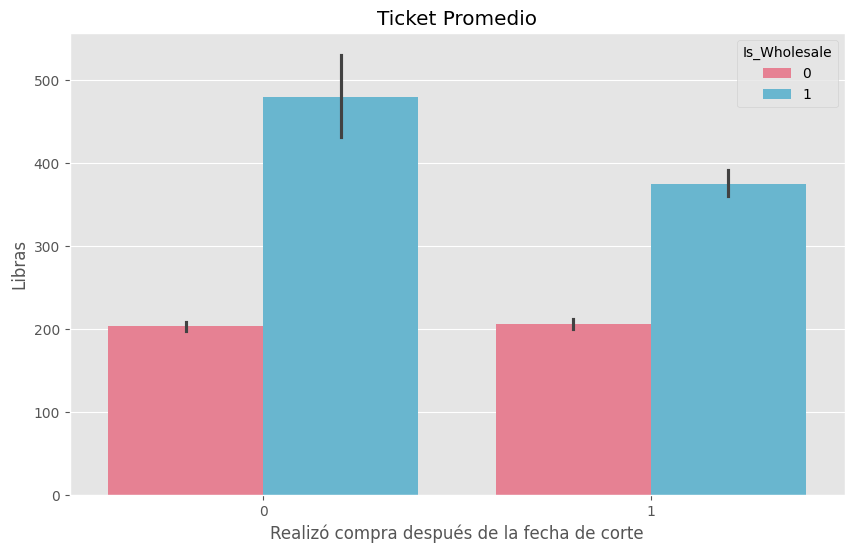

In [31]:
# gráfico de barras agrupadas de ticket promedio y promedio de quantity segmentado por la variable objetivo

plt.figure(figsize=(10, 6))
sns.barplot(data=customer_stats, x='Purchase', y='Avg_Ticket_Revenue', hue='Is_Wholesale', 
            palette={0: sns.color_palette('husl')[0], 1: "#58BEE0"})
plt.title("Ticket Promedio")
plt.ylabel("Libras")
plt.xlabel("Realizó compra después de la fecha de corte")
plt.show()

In [24]:
# La categoría de referencia es la primera alphabéticamente
categoria_referencia = sorted(customer_stats['Country'].unique())[0]
print(f"Categoría de referencia: {categoria_referencia}")

Categoría de referencia: EIRE


In [25]:
# Eliminación de total_revenue y customer_id

df_modelo = customer_stats.drop(columns=['Customer ID', 'Total_Revenue'])

# One-hot encoding de la variable Country
df_modelo = pd.get_dummies(df_modelo, columns=['Country'], drop_first=True, dtype=int)

In [26]:
# Guardamos el dataset limpio para futuros análisis
df_modelo.to_pickle('customer_stats_model.pkl')

In [27]:
df_modelo.head()

,Total_tickets,Avg_Ticket_Revenue,Avg_Ticket_Quantity,Is_Wholesale,total_cancellations,Recency,Purchase,Country_France,Country_Germany,Country_Others,Country_United Kingdom
0,6.0,43.230,22.0,0,12.0,398.0,0,0,0,0,1
1,4.0,528.025,138.5,1,0.0,52.0,1,0,0,1,0
2,2.0,78.090,89.0,0,0.0,117.0,0,0,0,1,0
3,1.5,908.545,67.0,0,0.0,276.0,1,0,0,1,0
4,1.0,294.400,49.0,0,0.0,179.0,0,0,0,1,0


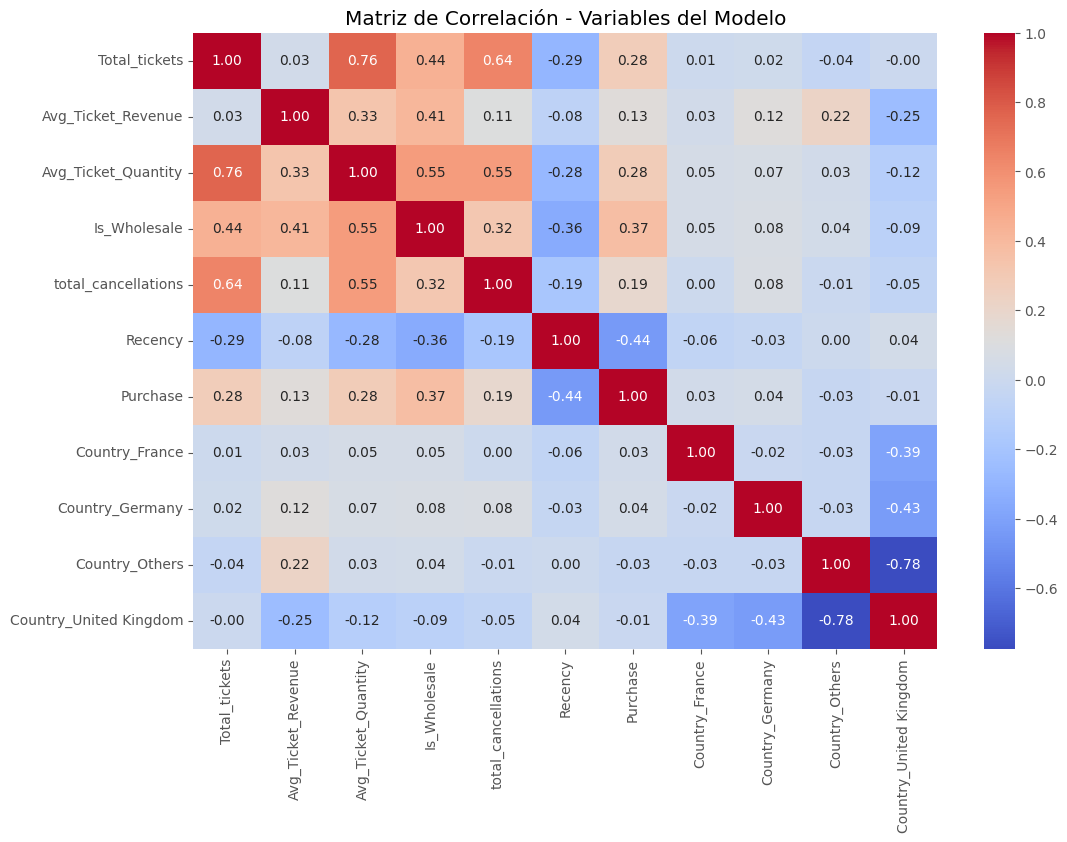

In [28]:
# Matriz de correlación para las variables del modelo
plt.figure(figsize=(12, 8))
sns.heatmap(df_modelo.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Matriz de Correlación - Variables del Modelo")
plt.show()

In [29]:
# Importación de librerías para el modelado
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                            confusion_matrix, RocCurveDisplay,
                            ConfusionMatrixDisplay, average_precision_score,
                            precision_recall_curve)
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV

In [30]:
# Separamos el dataset en características (X) y variable objetivo (y)
X = df_modelo.drop(columns=['Purchase'])
y = df_modelo['Purchase']

# Normalizamos las variables numéricas para el modelo
scaler = StandardScaler()
numerical_cols = ['Total_tickets', 'Avg_Ticket_Revenue', 'Avg_Ticket_Quantity', 'total_cancellations', 'Recency']
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
X.head()

,Total_tickets,Avg_Ticket_Revenue,Avg_Ticket_Quantity,Is_Wholesale,total_cancellations,Recency,Country_France,Country_Germany,Country_Others,Country_United Kingdom
0,0.365921,-1.084136,-0.453849,0,0.845612,1.398816,0,0,0,1
1,0.042968,1.528757,1.046810,1,-0.286789,-0.858791,0,0,1,0
2,-0.279984,-0.896252,0.409191,0,-0.286789,-0.434674,0,0,1,0
3,-0.360722,3.579642,0.125804,0,-0.286789,0.602781,0,0,1,0
4,-0.441461,0.269592,-0.106057,0,-0.286789,-0.030132,0,0,1,0


In [31]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    "Random Forest":       RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                                        use_label_encoder=False, eval_metric="logloss",
                                        random_state=42, n_jobs=-1, verbosity=0),
}

results   = {}
cv_scores = {}

for name, mdl in MODELS.items():
    print(f"\n  Training {name} …")
    X_tr = X_train if name == "Logistic Regression" else X_train.values
    X_te = X_test  if name == "Logistic Regression" else X_test.values

    # 5-fold CV AUC
    cv_auc = cross_val_score(mdl, X_tr, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_scores[name] = cv_auc
    print(f"    CV AUC  : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

    mdl.fit(X_tr, y_train)
    prob = mdl.predict_proba(X_te)[:, 1]
    pred = mdl.predict(X_te)

    auc  = roc_auc_score(y_test, prob)
    ap   = average_precision_score(y_test, prob)
    rep  = classification_report(y_test, pred, output_dict=True)
    results[name] = {"model": mdl, "prob": prob, "pred": pred,
                    "auc": auc, "ap": ap, "report": rep,
                    "X_tr": X_tr, "X_te": X_te}
    print(f"    Test AUC: {auc:.4f}   Avg-Precision: {ap:.4f}")
    print(f"    {classification_report(y_test, pred, digits=3)}")

# ── Best model ───────────────────────────────────────────
best_name = max(results, key=lambda k: results[k]["auc"])
best      = results[best_name]
print(f"\n  ✦ Best model: {best_name}  (AUC = {best['auc']:.4f})")


  Training Logistic Regression …
    CV AUC  : 0.8112 ± 0.0077
    Test AUC: 0.8179   Avg-Precision: 0.8300
                  precision    recall  f1-score   support

           0      0.741     0.796     0.767       504
           1      0.762     0.701     0.730       469

    accuracy                          0.750       973
   macro avg      0.751     0.749     0.749       973
weighted avg      0.751     0.750     0.750       973


  Training Random Forest …
    CV AUC  : 0.8931 ± 0.0035
    Test AUC: 0.8991   Avg-Precision: 0.8974
                  precision    recall  f1-score   support

           0      0.820     0.867     0.843       504
           1      0.848     0.795     0.821       469

    accuracy                          0.832       973
   macro avg      0.834     0.831     0.832       973
weighted avg      0.833     0.832     0.832       973


  Training Gradient Boosting …
    CV AUC  : 0.8990 ± 0.0043
    Test AUC: 0.9005   Avg-Precision: 0.8990
                  p

### (Opcional) Búsqueda de hiperparámetros
randomsearch, gridsearch, optuna, 


In [33]:
# importacion de optuna para la optimización de hiperparámetros
import optuna

# Optimización de hiperparámetros para el modelo Gradient Boosting
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True)
    }
    model = GradientBoostingClassifier(**params, random_state=42)
    cv_auc = cross_val_score(model, X_train.values, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    return cv_auc.mean()
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
print("Best hyperparameters:", study.best_params)


[I 2026-06-03 12:50:27,044] A new study created in memory with name: no-name-41539d0f-fa50-4e3b-933b-2e9e73bf7c82
[I 2026-06-03 12:50:28,713] Trial 0 finished with value: 0.8931606527193828 and parameters: {'n_estimators': 193, 'max_depth': 7, 'learning_rate': 0.07455185703780029}. Best is trial 0 with value: 0.8931606527193828.
[I 2026-06-03 12:50:32,921] Trial 1 finished with value: 0.8929460744032214 and parameters: {'n_estimators': 303, 'max_depth': 9, 'learning_rate': 0.04486592932723478}. Best is trial 0 with value: 0.8931606527193828.
[I 2026-06-03 12:50:33,924] Trial 2 finished with value: 0.896263786097313 and parameters: {'n_estimators': 256, 'max_depth': 3, 'learning_rate': 0.029767213872677896}. Best is trial 2 with value: 0.896263786097313.
[I 2026-06-03 12:50:37,472] Trial 3 finished with value: 0.8937257449345586 and parameters: {'n_estimators': 308, 'max_depth': 8, 'learning_rate': 0.035177892634907205}. Best is trial 2 with value: 0.896263786097313.
[I 2026-06-03 12:50

Best hyperparameters: {'n_estimators': 134, 'max_depth': 5, 'learning_rate': 0.024801688450893176}


In [34]:
# Mejor modelos con hiperparámetros optimizados
best_gb = GradientBoostingClassifier(**study.best_params, random_state=42)
best_gb.fit(X_train.values, y_train)

y_prob_gb = best_gb.predict_proba(X_test.values)[:, 1]
y_pred_gb = best_gb.predict(X_test.values)

print('=== Evaluación del Mejor Modelo (Gradient Boosting) ===')
print(classification_report(y_test, y_pred_gb, digits=4))
print(f"AUC: {roc_auc_score(y_test, y_prob_gb):.4f}   Avg-Precision: {average_precision_score(y_test, y_prob_gb):.4f}")



=== Evaluación del Mejor Modelo (Gradient Boosting) ===
              precision    recall  f1-score   support

           0     0.8330    0.8512    0.8420       504
           1     0.8362    0.8166    0.8263       469

    accuracy                         0.8345       973
   macro avg     0.8346    0.8339    0.8342       973
weighted avg     0.8346    0.8345    0.8344       973

AUC: 0.9086   Avg-Precision: 0.9095


El modelo de partida ya era bastante bueno sin necesidad de optimizar parámetros. Hemos conseguido mejora en las centésimas. 

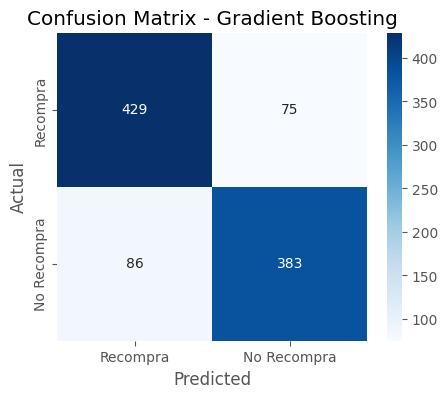

In [35]:
# Confusion Matrix
preds = best_gb.predict(X_test.values)
cm = confusion_matrix(y_test, preds, labels=best_gb.classes_)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Recompra', 'No Recompra'],
            yticklabels=['Recompra', 'No Recompra'],
            ax=ax)
plt.xlabel('Predicted') 
plt.ylabel('Actual')
plt.title('Confusion Matrix - Gradient Boosting')
plt.show()


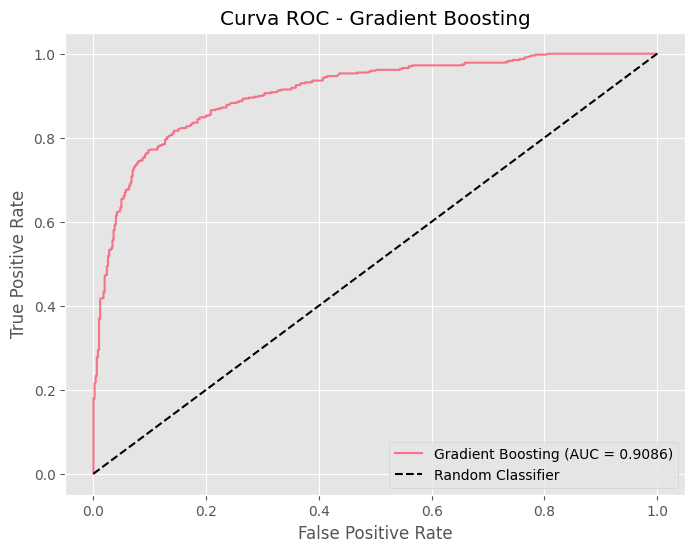

In [36]:
# Curva ROC
auc = roc_auc_score(y_test, y_prob_gb)
fpr, tpr, _ = roc_curve(y_test, y_prob_gb)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Gradient Boosting (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Gradient Boosting')
plt.legend()
plt.show()


## 8. Modelo: explicabilidad
indicar las variables más relevantes del modelo. COn Dalex o más sencillo, los propios  tiene manera de obtener las variables:   
Ej. 

from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()



In [37]:
import dalex
import warnings
warnings.filterwarnings("ignore")
# Matrices procesadas a dataframes
X_train_df = pd.DataFrame(X_train, columns=df_modelo.drop(columns=['Purchase']).columns)
X_test_df = pd.DataFrame(X_test, columns=df_modelo.drop(columns=['Purchase']).columns)

# Explainer de dalex para el modelo de Gradient Boosting
explainer_gb = dalex.Explainer(best_gb, X_test_df, y_test, label="Gradient Boosting")

# Importancia global de las variables
importance_gb = explainer_gb.model_parts()
importance_gb.plot()



Preparation of a new explainer is initiated

  -> data              : 973 rows 10 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 973 values
  -> model_class       : sklearn.ensemble._gb.GradientBoostingClassifier (default)
  -> label             : Gradient Boosting
  -> predict function  : <function yhat_proba_default at 0x000001B86DBF1850> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.0332, mean = 0.488, max = 0.956
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.935, mean = -0.00555, max = 0.926
  -> model_info        : package sklearn

A new explainer has been created!
